In [2]:
# imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")



In [ ]:
# load data

csv_path = "/Users/erincheng/Desktop/telco-customer-churn/data/raw/telco-customer-churn.csv"

df = pd.read_csv(csv_path)

# preview
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [14]:
# clean type issues

if "TotalCharges" in df.columns and df["TotalCharges"].dtype == "object":
    df["TotalCharges"] = pd.to_numeric(
        df["TotalCharges"].replace(" ", np.nan),
        errors="coerce"
    )

df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Churn counts:
 Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn rate: 26.54%


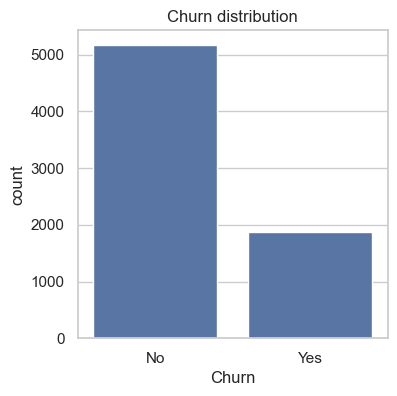

In [5]:
# target variable distribution

if "Churn" in df.columns:
    churn_counts = df["Churn"].value_counts(dropna=False)
    churn_rate = churn_counts.get("Yes", 0) / churn_counts.sum()
    print("Churn counts:\n", churn_counts)
    print(f"Churn rate: {churn_rate:.2%}")

    plt.figure(figsize = (4,4))
    sns.countplot(x="Churn", data=df)
    plt.title("Churn distribution")
    plt.show()


categorical columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


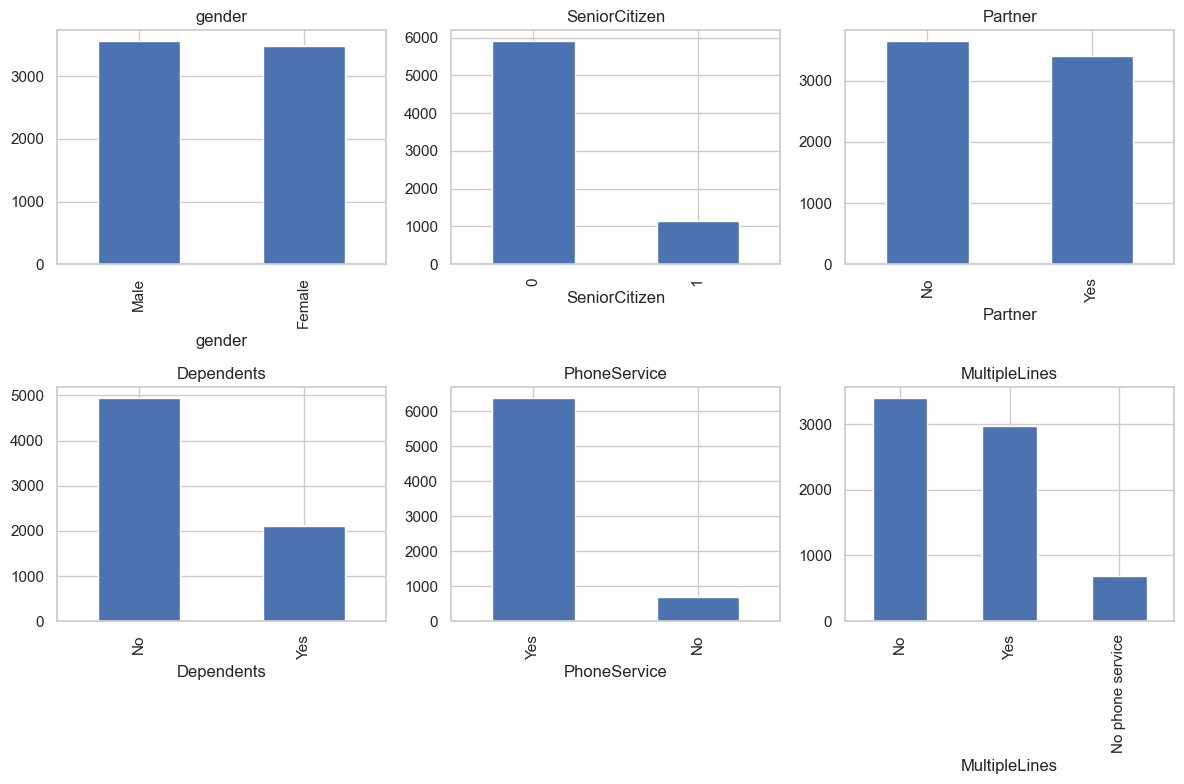

In [13]:
# categorical feature distributions

categorical_cols = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]


categorical_cols = [c for c in categorical_cols if c in df.columns]
print("categorical columns:", categorical_cols) 

plt.figure(figsize=(12, 8))
for i, col in enumerate(categorical_cols[:6], start=1):
    plt.subplot(2, 3, i)
    df[col].value_counts().plot(kind="bar")
    plt.title(col)
    plt.tight_layout()
plt.show()

Numeric columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges']


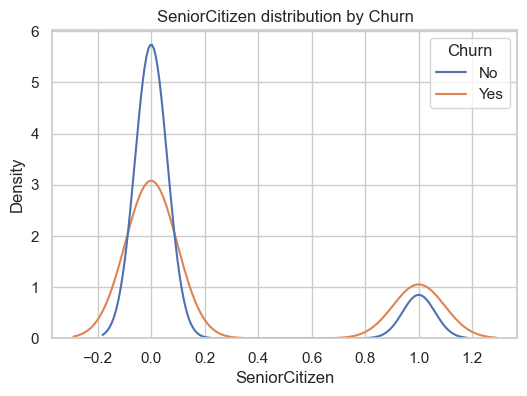

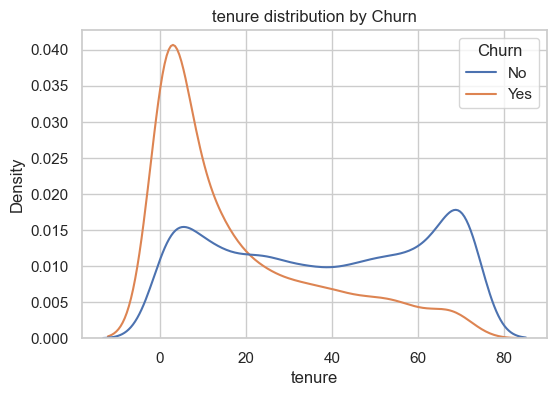

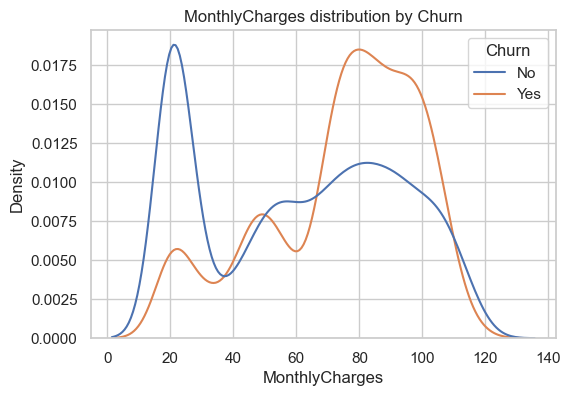

In [16]:
# numeric feature distributions by churn

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("Numeric columns:", numeric_cols)

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.kdeplot(data=df, x=col, hue="Churn", common_norm=False)
    plt.title(f"{col} distribution by Churn")
    plt.show()

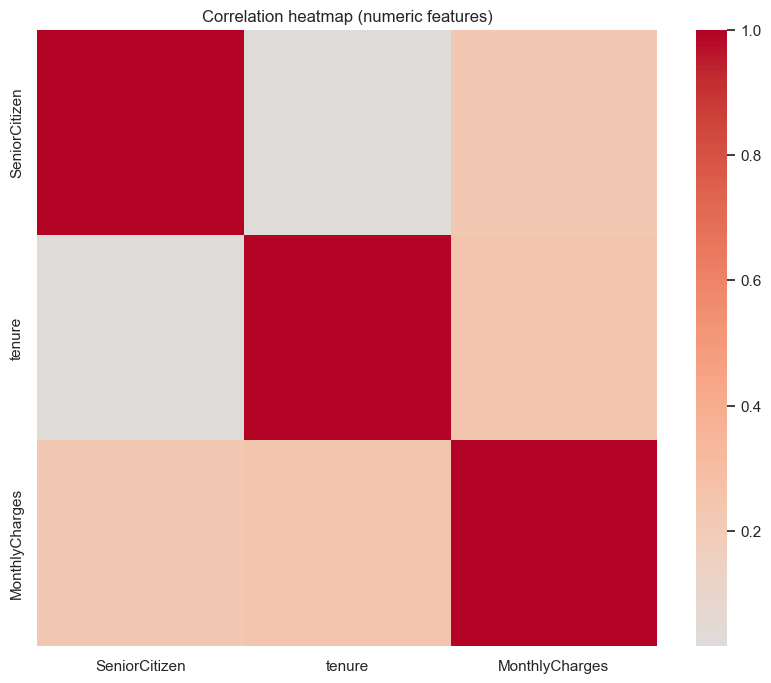

In [15]:
# correlation heatmap

plt.figure(figsize=(10,8))
cor = df[numeric_cols].corr()
sns.heatmap(cor, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation heatmap (numeric features)")
plt.show()

In [12]:
# save sample

sample = df.sample(n=min(1000, len(df)), random_state=42)
sample.to_csv("/Users/erincheng/Desktop/telco-customer-churn/data/sample/telco_sample_1k.csv", index=False)